In [53]:
import pandas as pd
import numpy as np

<sub style="font-size: 0.8em;">*Note on Data Access: For privacy and security reasons, the local directory paths used to **load and save** data (via `read_excel` and `to_excel`) have been removed or replaced with generic placeholders. If you are attempting to run this notebook, please ensure the data file is located in your working directory and update the file paths accordingly.*</sub>

## Data Cleaning & Preprocessing

In [ ]:
# importing the compiled data
tourism = pd.read_excel(r"C:\Users\YOUR FILE PATH\tourism.xlsx") # Add your own file path
tourism.set_index('Date',inplace=True)
tourism.index = tourism.index.to_period('M') # Convert the date fromat to a PeriodIndex with monthly frequency (year and month)
tourism = tourism.rename(columns={'Overnight Visitors In Mlns': 'visitors_mln'})
print(tourism.info())
tourism.head()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 144 entries, 2014-01 to 2025-12
Freq: M
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   visitors_mln  144 non-null    float64
dtypes: float64(1)
memory usage: 2.2 KB
None


,visitors_mln
Date,
2014-01,1.246513
2014-02,1.157455
2014-03,1.210956
2014-04,1.165982
2014-05,1.060230


In [ ]:
# import yearly population data
population = pd.read_excel(r"C:\Users\YOUR FILE PATH\population.xlsx")

# rename columns for clarity
population = population.rename(columns={
    'Date': 'year',
    'Total Residents': 'population'
})

# create monthly rows by repeating each year's population for all 12 months
population_monthly = population.loc[population.index.repeat(12)].copy()
population_monthly['month'] = list(range(1, 13)) * len(population)

# build monthly period labels in YYYY-MM format
population_monthly['Date'] = pd.PeriodIndex(
    population_monthly['year'].astype(str) + '-' + population_monthly['month'].astype(str).str.zfill(2),
    freq='M'
)

# keep only the final monthly series
population_monthly = population_monthly[['Date', 'population']]
population_monthly.set_index('Date', inplace=True)


print(population_monthly.info())
population_monthly.head(15)

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 144 entries, 2013-01 to 2024-12
Freq: M
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   population  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


,population
Date,
2013-01,2213845
2013-02,2213845
2013-03,2213845
2013-04,2213845
2013-05,2213845
2013-06,2213845
2013-07,2213845
2013-08,2213845
2013-09,2213845


In [56]:
# start from the monthly population series
population_interp = population_monthly.copy()

# keep only December values as annual anchor points, set other months to missing
population_interp.loc[population_interp.index.month != 12, 'population'] = pd.NA

# interpolate linearly across months
population_interp['population'] = population_interp['population'].interpolate(method='linear')

# align interpolated monthly population to the tourism sample dates
population_interp = population_interp.reindex(tourism.index)

# convert population from persons to millions
population_interp['population_mln'] = population_interp['population'] / 1_000_000

# keep only the population in millions
population_interp = population_interp[['population_mln']]

population_interp.head()

,population_mln
Date,
2014-01,2.223304
2014-02,2.232763
2014-03,2.242221
2014-04,2.251680
2014-05,2.261139


In [57]:
# merge tourism inflows with monthly interpolated population in millions
tourism_pressure = tourism.merge(population_interp, left_index=True, right_index=True, how='left')

# calculate the monthly tourist-to-resident ratio
tourism_pressure['tourist_to_resident_ratio'] = tourism_pressure['visitors_mln'] / tourism_pressure['population_mln']

# calculate the monthly tourist-to-resident ratio
# calculate the monthly tourist-to-resident ratio
tourism_pressure['tourist_to_resident_ratio'] = tourism_pressure['tourist_to_resident_ratio'].round(2)

tourism_pressure.head(15)

,visitors_mln,population_mln,tourist_to_resident_ratio
Date,,,
2014-01,1.246513,2.223304,0.56
2014-02,1.157455,2.232763,0.52
2014-03,1.210956,2.242221,0.54
2014-04,1.165982,2.251680,0.52
2014-05,1.060230,2.261139,0.47
2014-06,0.982064,2.270598,0.43
2014-07,0.705354,2.280056,0.31
2014-08,1.061967,2.289515,0.46
2014-09,1.007834,2.298974,0.44


In [ ]:
# import rent index
rent = pd.read_excel(r"C:\Users\YOUR FILE PATH\Rent Index.xlsx")

# make sure date column is correct
rent['Date'] = pd.to_datetime(rent['Date'])
rent.set_index('Date', inplace=True)

# convert to monthly period index (same as tourism)
rent.index = rent.index.to_period('M')
rent['rent_change'] = rent['Rent Index'].pct_change() # Calculate % change

# check columns
print(rent.columns)
rent.head()

Index(['Rent Index', 'rent_change'], dtype='object')


,Rent Index,rent_change
Date,,
2012-12,1.010,NaN
2013-01,1.000,-0.009901
2013-02,0.995,-0.005000
2013-03,0.995,0.000000
2013-04,1.006,0.011055


In [ ]:
# import cpi index
cpi = pd.read_excel(r"C:\Users\YOUR FILE PATH\Dubai CPI.xlsx")

# make sure date column is correct
cpi['Date'] = pd.to_datetime(cpi['Date'])
cpi.set_index('Date', inplace=True)

# convert to monthly period index (same as tourism)
cpi.index = cpi.index.to_period('M')

# check columns
print(cpi.columns)
cpi.head()

Index(['Base Year', 'General Index', 'Food and beverages', 'Tobacco',
       'Clothing and footwear',
       'Housing, water, electricity, gas and other fuels',
       'Furnishings, household equipment and maintenance', 'Health',
       'Transport', 'Communication / Info & communication',
       'Recreation, sport and culture', 'Education',
       'Restaurants and hotels / accommodation',
       'Insurance and financial services',
       'Personal care, social protection & misc. goods'],
      dtype='object')


C:\Users\USER\AppData\Local\Temp\ipykernel_15536\415404718.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cpi['Date'] = pd.to_datetime(cpi['Date'])


,Base Year,General Index,Food and beverages,Tobacco,Clothing and footwear,"Housing, water, electricity, gas and other fuels","Furnishings, household equipment and maintenance",Health,Transport,Communication / Info & communication,"Recreation, sport and culture",Education,Restaurants and hotels / accommodation,Insurance and financial services,"Personal care, social protection & misc. goods"
Date,,,,,,,,,,,,,,,
2014-01,2007=100,117.48,141.90,136.57,121.55,100.91,128.17,124.16,131.93,90.39,108.83,174.00,144.12,NaN,129.59
2014-02,2007=100,117.97,140.88,136.57,121.55,101.56,127.98,123.77,132.10,90.34,108.83,174.00,147.65,NaN,131.73
2014-03,2007=100,118.52,142.59,136.57,121.43,101.93,133.88,124.29,132.02,90.35,108.18,175.47,147.69,NaN,132.25
2014-04,2007=100,118.63,140.16,136.57,121.43,102.57,134.02,124.29,131.94,91.72,108.18,175.47,147.66,NaN,131.65
2014-05,2007=100,118.84,141.82,136.57,121.43,102.61,133.96,124.60,131.82,91.75,107.97,175.47,147.60,NaN,132.07


In [60]:
# columns to adjust
cpi_cols = cpi.columns.drop('Base Year')

# --- compute link factors ---
old_2014 = cpi[(cpi.index.year == 2014) & (cpi['Base Year'] == '2007=100')]
old_2021 = cpi[(cpi.index.year == 2021) & (cpi['Base Year'] == '2014=100')]

link_2007_to_2014 = 100 / old_2014[cpi_cols].mean()
link_2014_to_2021 = 100 / old_2021[cpi_cols].mean()
link_2007_to_2021 = link_2007_to_2014 * link_2014_to_2021

# --- apply chain-linking ---
cpi_linked = cpi.copy()

mask_2007 = cpi['Base Year'] == '2007=100'
mask_2014 = cpi['Base Year'] == '2014=100'

cpi_linked.loc[mask_2007, cpi_cols] = cpi.loc[mask_2007, cpi_cols].mul(link_2007_to_2021, axis=1)
cpi_linked.loc[mask_2014, cpi_cols] = cpi.loc[mask_2014, cpi_cols].mul(link_2014_to_2021, axis=1)

# done → cpi_linked is now all in 2021=100

In [61]:
# rename the CPI columns for easier reference
cpi_linked = cpi_linked.rename(columns={
    'Food and beverages': 'food_cpi',
    'Housing, water, electricity, gas and other fuels': 'housing_cpi',
    'Transport': 'transport_cpi',
    'Recreation, sport and culture': 'recreation_cpi',
    'Restaurants and hotels / accommodation': 'resthot_cpi'
})

In [62]:
# calculate monthly % changes for each category
cpi_linked['food_change'] = cpi_linked['food_cpi'].pct_change() 
cpi_linked['housing_change'] = cpi_linked['housing_cpi'].pct_change() 
cpi_linked['transport_change'] = cpi_linked['transport_cpi'].pct_change() 
cpi_linked['recreation_change'] = cpi_linked['recreation_cpi'].pct_change() 
cpi_linked['resthot_change'] = cpi_linked['resthot_cpi'].pct_change() 

In [63]:
# keep only what you need from each dataset
tourism_ratio = tourism_pressure[['tourist_to_resident_ratio']].copy()
rent_data = rent[['rent_change']].copy()

cpi_changes = cpi_linked[[
    'food_change',
    'housing_change',
    'transport_change',
    'recreation_change',
    'resthot_change'
]].copy()

In [64]:
master_data = tourism_ratio.merge(rent_data, left_index=True, right_index=True, how='left')
master_data = master_data.merge(cpi_changes, left_index=True, right_index=True, how='left')

master_data = master_data.dropna()
print(master_data.info())

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 131 entries, 2014-02 to 2024-12
Freq: M
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   tourist_to_resident_ratio  131 non-null    float64
 1   rent_change                131 non-null    float64
 2   food_change                131 non-null    float64
 3   housing_change             131 non-null    float64
 4   transport_change           131 non-null    float64
 5   recreation_change          131 non-null    float64
 6   resthot_change             131 non-null    float64
dtypes: float64(7)
memory usage: 8.2 KB
None


In [65]:
master_data.head()

,tourist_to_resident_ratio,rent_change,food_change,housing_change,transport_change,recreation_change,resthot_change
Date,,,,,,,
2014-02,0.52,0.006341,-0.007188,0.006441,0.001289,0.000000,0.024493
2014-03,0.54,0.017102,0.012138,0.003643,-0.000606,-0.005973,0.000271
2014-04,0.52,0.022124,-0.017042,0.006279,-0.000606,0.000000,-0.000203
2014-05,0.47,0.019913,0.011844,0.000390,-0.000910,-0.001941,-0.000406
2014-06,0.43,0.016129,0.016641,0.001657,0.017600,-0.001297,0.006504


## Exploratory Data Analysis

##### All charts, graphs, etc, were saved in excel for cleaner visuals for the main report, all graphs and charts shown here were for illustrative purposes only

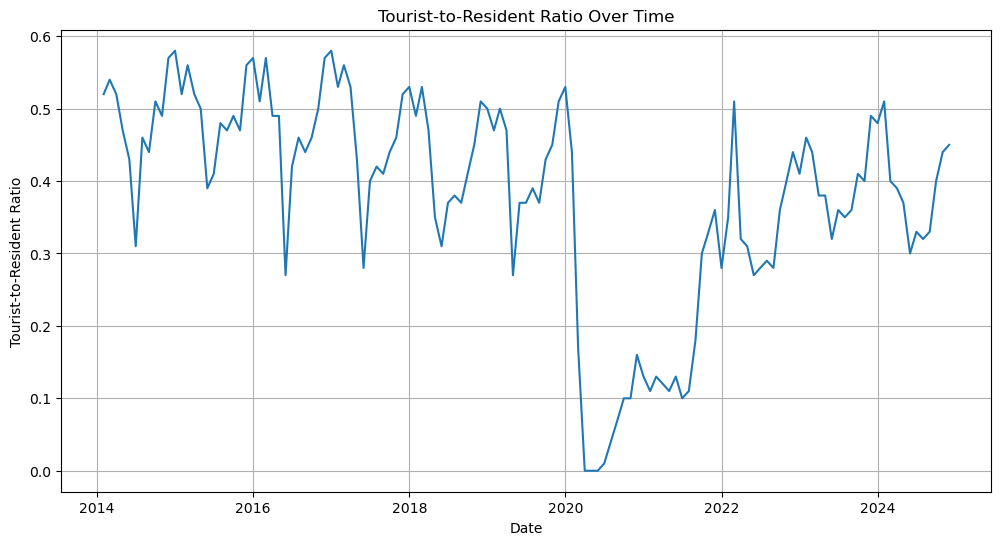

In [66]:
# =============================================================
# STEP: Time series plot for tourist-to-resident ratio
# =============================================================

import matplotlib.pyplot as plt

x = master_data.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(x, master_data['tourist_to_resident_ratio'])
plt.title('Tourist-to-Resident Ratio Over Time')
plt.xlabel('Date')
plt.ylabel('Tourist-to-Resident Ratio')
plt.grid()
plt.show()

In [ ]:
# Exporting the master dataset to Excel

master_data_export = master_data.copy()
master_data_export.index = master_data_export.index.to_timestamp()

master_data_export = master_data_export.reset_index()
master_data_export.rename(columns={'index': 'Date'}, inplace=True)

file_path = r"C:\Users\YOUR FILE PATH\EDA\tourism_eda.xlsx"

master_data_export.to_excel(file_path, index=False)

In [68]:
# Removing covid data
covid_exclusion = (master_data.index >= '2020-03') & (master_data.index <= '2021-09')
master_data_clean = master_data[~covid_exclusion]

In [69]:
# =============================================================
# STEP: Summary statistics for tourist-to-resident ratio
# =============================================================

ratio_stats = master_data_clean[['tourist_to_resident_ratio']].describe()

ratio_stats = ratio_stats.rename(index={
    'count': 'Observations',
    'mean':  'Mean',
    'std':   'Std. Deviation',
    'min':   'Minimum',
    '25%':   '25th Percentile',
    '50%':   'Median',
    '75%':   '75th Percentile',
    'max':   'Maximum'
})

ratio_stats.columns = ['Tourist-to-Resident Ratio']

print(ratio_stats.round(2))

                 Tourist-to-Resident Ratio
Observations                        112.00
Mean                                  0.43
Std. Deviation                        0.08
Minimum                               0.27
25th Percentile                       0.37
Median                                0.44
75th Percentile                       0.50
Maximum                               0.58


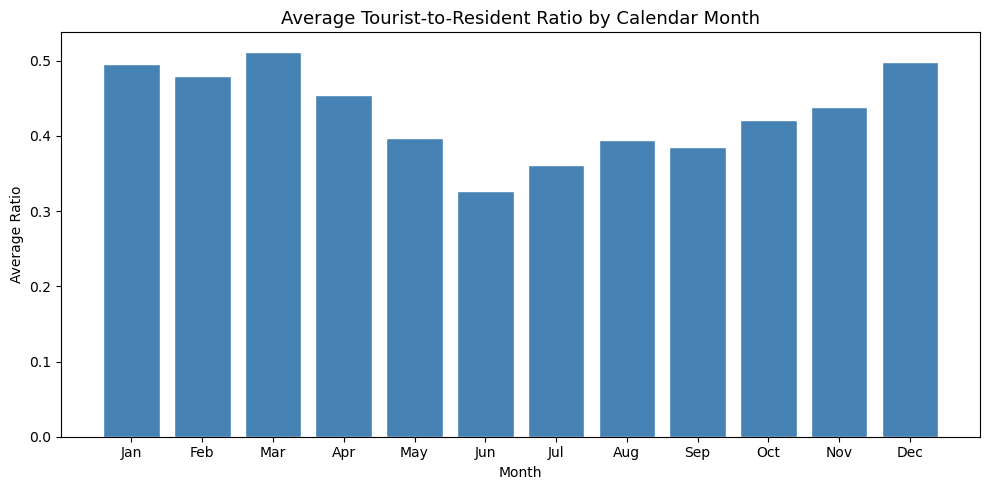

In [70]:
# =============================================================
# STEP: Monthly average for tourist-to-resident ratio
# =============================================================

import matplotlib.pyplot as plt

seasonal = master_data_clean.copy()
seasonal['month'] = master_data_clean.index.month

monthly_avg = seasonal.groupby('month')['tourist_to_resident_ratio'].mean()

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(month_labels, monthly_avg.values, color='steelblue', edgecolor='white')
ax.set_title('Average Tourist-to-Resident Ratio by Calendar Month', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Average Ratio')
plt.tight_layout()
plt.show()

In [ ]:
# Export monthly averages to Excel
seasonal = master_data_clean.copy()
seasonal['month'] = master_data_clean.index.month
monthly_avg = seasonal.groupby('month')['tourist_to_resident_ratio'].mean()
file_path2 = r"C:\Users\YOUR FILE PATH\EDA\monthly_avg_eda.xlsx"
monthly_avg.to_excel(file_path2, index=False)

In [ ]:
# Forgot to export cleaned master dataset to Excel (without covid period)

master_data_clean = master_data.copy()
master_data_clean.index = master_data_clean.index.to_timestamp()

master_data_clean = master_data_clean.reset_index()
master_data_clean.rename(columns={'index': 'Date'}, inplace=True)

file_path3 = r"C:\Users\YOUR FILE PATH\EDA\master_data_clean.xlsx"

master_data_clean.to_excel(file_path3, index=False)

In [73]:
# =============================================================
# STEP: Split master_data into pre-COVID and post-COVID periods
# =============================================================

# I'm splitting the data into two clean, internally consistent periods
# rather than removing COVID months from a single series.
# This avoids any cross-gap pairing when I apply lags later.
# Pre-COVID: Jan 2017 – Feb 2020 (last clean month before collapse)
# Post-COVID: Oct 2021 – Dec 2024 (first month tourism meaningfully resumed)
# I start pre-COVID from 2017-01 because that is my study period start.

pre_covid = master_data[
    (master_data.index >= pd.Period('2017-01', freq='M')) &
    (master_data.index <= pd.Period('2020-02', freq='M'))
].copy()

post_covid = master_data[
    (master_data.index >= pd.Period('2021-10', freq='M')) &
    (master_data.index <= pd.Period('2024-12', freq='M'))
].copy()

print(f"Pre-COVID rows:  {len(pre_covid)}  ({pre_covid.index.min()} to {pre_covid.index.max()})")
print(f"Post-COVID rows: {len(post_covid)}  ({post_covid.index.min()} to {post_covid.index.max()})")

Pre-COVID rows:  38  (2017-01 to 2020-02)
Post-COVID rows: 39  (2021-10 to 2024-12)


## Correlation Analysis

In [74]:
# =============================================================
# STEP: Build lagged datasets for each period
# =============================================================

# I define my dependent variables once and reuse this list throughout.
dependent_vars = [
    'rent_change',
    'food_change',
    'housing_change',
    'transport_change',
    'recreation_change',
    'resthot_change'
]

def build_lags(period_df):
    """
    Takes a clean period dataframe (no COVID gap inside it) and returns
    three lagged versions — t+1, t+2, t+3.
    
    shift(-1) moves dependent variable values UP by 1 row, so that the 
    tourism ratio in row t gets paired with the price change in row t+1.
    dropna() removes the final rows that have no lag partner after shifting.
    Because there is no gap inside either period, shift() is safe — every 
    pairing is a genuine consecutive month.
    """
    # Lag 1: price change one month after tourism observation
    lag1 = period_df.copy()
    lag1[dependent_vars] = lag1[dependent_vars].shift(-1)
    lag1 = lag1.dropna()
    lag1 = lag1.rename(columns={col: f"{col}_t1" for col in dependent_vars})

    # Lag 2: price change two months after tourism observation
    lag2 = period_df.copy()
    lag2[dependent_vars] = lag2[dependent_vars].shift(-2)
    lag2 = lag2.dropna()
    lag2 = lag2.rename(columns={col: f"{col}_t2" for col in dependent_vars})

    # Lag 3: price change three months after tourism observation
    lag3 = period_df.copy()
    lag3[dependent_vars] = lag3[dependent_vars].shift(-3)
    lag3 = lag3.dropna()
    lag3 = lag3.rename(columns={col: f"{col}_t3" for col in dependent_vars})

    return lag1, lag2, lag3

# Build lags separately for each period — no cross-gap contamination possible
pre_lag1,  pre_lag2,  pre_lag3  = build_lags(pre_covid)
post_lag1, post_lag2, post_lag3 = build_lags(post_covid)

print("Pre-COVID lag sizes:  ", len(pre_lag1),  len(pre_lag2),  len(pre_lag3))
print("Post-COVID lag sizes: ", len(post_lag1), len(post_lag2), len(post_lag3))

Pre-COVID lag sizes:   37 36 35
Post-COVID lag sizes:  38 37 36


In [75]:
# =============================================================
# STEP: Run Pearson correlations for each period and each lag
# =============================================================

# For each lagged dataset I calculate the Pearson r and p-value between
# tourist_to_resident_ratio and each lagged price change variable.
# p < 0.05 is my significance threshold throughout.

from scipy import stats

def run_correlations(lag_df, lag_suffix, lag_label):
    """
    Computes Pearson r and p-value between tourism ratio and each 
    dependent variable in the lagged dataframe.
    lag_suffix: the column name ending e.g. '_t1'
    lag_label:  the readable label e.g. 't+1'
    """
    results = []
    dep_cols = [f"{v}{lag_suffix}" for v in dependent_vars]
    for col in dep_cols:
        r, p = stats.pearsonr(
            lag_df['tourist_to_resident_ratio'],
            lag_df[col]
        )
        results.append({
            'Lag':                  lag_label,
            'Variable':             col.replace(lag_suffix, ''),
            'r':                    round(r, 4),
            'p_value':              round(p, 4),
            'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'
        })
    return pd.DataFrame(results)

# --- Pre-COVID correlations ---
pre_results = pd.concat([
    run_correlations(pre_lag1,  '_t1', 't+1'),
    run_correlations(pre_lag2,  '_t2', 't+2'),
    run_correlations(pre_lag3,  '_t3', 't+3'),
], ignore_index=True)

# --- Post-COVID correlations ---
post_results = pd.concat([
    run_correlations(post_lag1, '_t1', 't+1'),
    run_correlations(post_lag2, '_t2', 't+2'),
    run_correlations(post_lag3, '_t3', 't+3'),
], ignore_index=True)

print("=== PRE-COVID ===")
print(pre_results.to_string(index=False))
print("\n=== POST-COVID ===")
print(post_results.to_string(index=False))

=== PRE-COVID ===
Lag          Variable       r  p_value Significant (p<0.05)
t+1       rent_change  0.0389   0.8193                   No
t+1       food_change -0.1615   0.3395                   No
t+1    housing_change  0.3170   0.0559                   No
t+1  transport_change  0.0961   0.5714                   No
t+1 recreation_change -0.0405   0.8120                   No
t+1    resthot_change  0.0612   0.7190                   No
t+2       rent_change  0.1011   0.5574                   No
t+2       food_change  0.0278   0.8723                   No
t+2    housing_change  0.2935   0.0823                   No
t+2  transport_change -0.0706   0.6824                   No
t+2 recreation_change -0.1896   0.2682                   No
t+2    resthot_change -0.0191   0.9118                   No
t+3       rent_change  0.1986   0.2527                   No
t+3       food_change  0.1448   0.4066                   No
t+3    housing_change  0.2797   0.1036                   No
t+3  transport_change 

In [76]:
# =============================================================
# STEP: Build summary pivot tables for heatmaps
# =============================================================

# I pivot results so variables are rows and lags are columns —
# the format my heatmap code below expects.
# I produce one heatmap per period so they can be read side by side.

pre_corr_summary  = pre_results.pivot(index='Variable',  columns='Lag', values='r')[['t+1','t+2','t+3']]
post_corr_summary = post_results.pivot(index='Variable', columns='Lag', values='r')[['t+1','t+2','t+3']]

print("Pre-COVID correlation summary:")
print(pre_corr_summary)
print("\nPost-COVID correlation summary:")
print(post_corr_summary)

Pre-COVID correlation summary:
Lag                   t+1     t+2     t+3
Variable                                 
food_change       -0.1615  0.0278  0.1448
housing_change     0.3170  0.2935  0.2797
recreation_change -0.0405 -0.1896 -0.1225
rent_change        0.0389  0.1011  0.1986
resthot_change     0.0612 -0.0191 -0.1645
transport_change   0.0961 -0.0706  0.2244

Post-COVID correlation summary:
Lag                   t+1     t+2     t+3
Variable                                 
food_change        0.0962  0.1309  0.0195
housing_change     0.1148 -0.0716 -0.1195
recreation_change  0.0475 -0.0139  0.0899
rent_change       -0.0314  0.0235  0.3235
resthot_change    -0.3761 -0.3229 -0.5593
transport_change   0.0200 -0.0412  0.2028


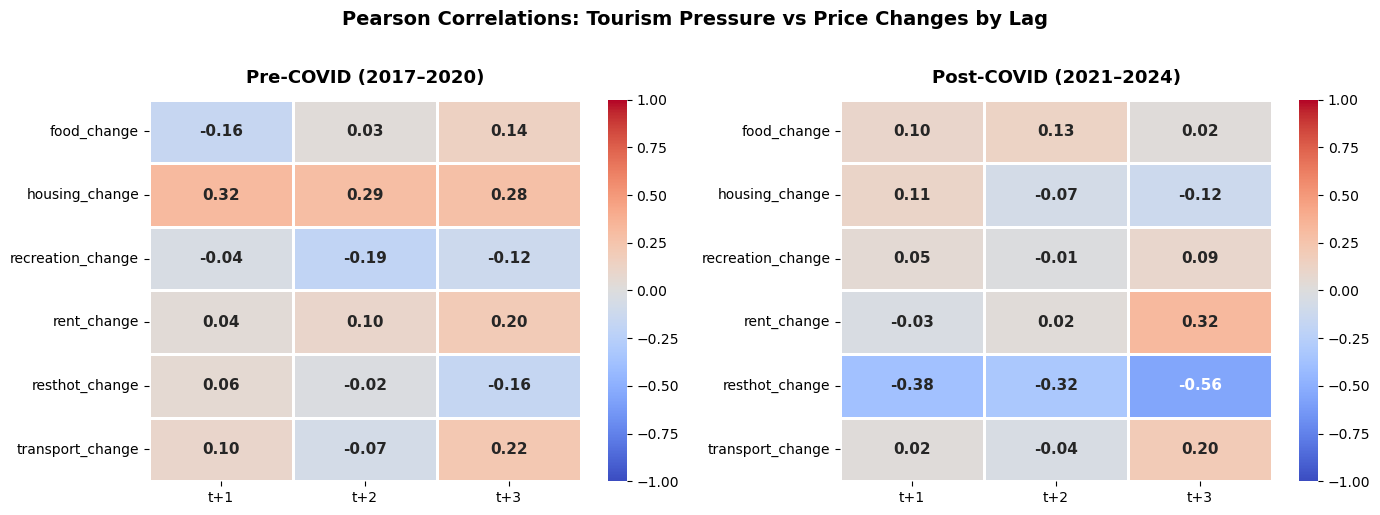

In [77]:
# =============================================================
# STEP: Plot side-by-side heatmaps for pre and post COVID
# =============================================================

# Showing both periods side by side makes it easy to see whether 
# the direction and strength of correlations is consistent across 
# both periods — which would strengthen the overall findings.
# I fix vmin/vmax at -1 and 1 since these are correlation coefficients
# and that is the full possible range.

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, summary, title in zip(
    axes,
    [pre_corr_summary, post_corr_summary],
    ['Pre-COVID (2017–2020)', 'Post-COVID (2021–2024)']
):
    sns.heatmap(
        summary,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.8,
        linecolor='white',
        annot_kws={"size": 11, "weight": "bold"},
        ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10, rotation=0)

plt.suptitle('Pearson Correlations: Tourism Pressure vs Price Changes by Lag',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('correlation_heatmap_split.png', dpi=180, bbox_inches='tight')
plt.show()

## Ordinary Least Squares (OLS) Regression

In [78]:
# =============================================================
# STEP: OLS Regression — All Lags, Pre and Post COVID
# =============================================================

# I run OLS regression separately for each combination of:
# - Period (pre-COVID, post-COVID)
# - Dependent variable (6 price change variables)
# - Lag (t+1, t+2, t+3)
# That gives 36 models in total.
#
# For each model I also run three diagnostic tests:
# - ADF (stationarity): checks the dependent variable is not trending
#   in a way that would make results spurious
# - Durbin-Watson (autocorrelation): checks residuals are not correlated
#   over time, which is common in monthly data
# - Breusch-Pagan (heteroskedasticity): checks residual variance is stable

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller

def run_adf(series):
    """
    Runs Augmented Dickey-Fuller test on a series.
    Null hypothesis: series has a unit root (non-stationary).
    If p < 0.05 I reject the null — series is stationary, which is what I want.
    Returns the p-value only for the summary table.
    """
    result = adfuller(series.dropna(), autolag='AIC')
    return round(result[1], 4)  # p-value

def run_ols_model(x, y):
    """
    Fits a simple OLS model: y = b0 + b1*x + e
    x: tourist_to_resident_ratio at time t
    y: price change at time t+k (already shifted before this function is called)
    Returns the fitted model and all diagnostic results in a dictionary.
    """
    # Add constant for intercept (b0)
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    # --- Extract core regression results ---
    b1        = round(model.params['tourist_to_resident_ratio'], 6)
    p_val     = round(model.pvalues['tourist_to_resident_ratio'], 4)
    r_squared = round(model.rsquared, 4)
    sig       = 'Yes' if p_val < 0.05 else 'No'

    # --- Durbin-Watson ---
    # Score ranges 0-4. Close to 2 = no autocorrelation.
    # Below 1.5 suggests positive autocorrelation (common in monthly data).
    # Above 2.5 suggests negative autocorrelation.
    dw = round(durbin_watson(model.resid), 4)

    # --- Breusch-Pagan ---
    # Tests whether residual variance is constant (homoskedastic).
    # Null: residuals are homoskedastic.
    # If p < 0.05: heteroskedasticity is present — standard errors may be unreliable.
    _, bp_p, _, _ = het_breuschpagan(model.resid, model.model.exog)
    bp_p = round(bp_p, 4)

    # --- ADF on dependent variable ---
    # I test stationarity on y (the dependent variable).
    # If p < 0.05 the series is stationary — safe to use in OLS.
    # If p >= 0.05 I flag it as a limitation.
    adf_p = run_adf(y)

    return {
        'β1':              b1,
        'p_value':         p_val,
        'Significant':     sig,
        'R²':              r_squared,
        'Durbin-Watson':   dw,
        'BP p-value':      bp_p,
        'ADF p-value':     adf_p,
    }

def run_all_ols(period_df, period_label):
    """
    Loops over all 6 dependent variables and all 3 lags for a given period.
    Returns a tidy dataframe of results across all 18 models for that period.
    """
    dependent_vars = [
        'rent_change',
        'food_change',
        'housing_change',
        'transport_change',
        'recreation_change',
        'resthot_change'
    ]

    results = []
    x_full = period_df['tourist_to_resident_ratio']

    for lag_k in [1, 2, 3]:
        # I shift the dependent variables forward by lag_k rows.
        # shift(-k) means: for tourism in month t, I pair it with the 
        # price change k months later. I align on the tourism index 
        # so x and y share the same row positions after shifting.
        shifted = period_df[dependent_vars].shift(-lag_k)

        # After shifting, the last k rows of x have no valid y partner.
        # I drop those rows by finding where shifted has NaN.
        valid_idx = shifted.dropna().index
        x = x_full.loc[valid_idx]

        for var in dependent_vars:
            y = shifted.loc[valid_idx, var]

            # Run the model and collect diagnostics
            model_results = run_ols_model(x, y)

            results.append({
                'Period':   period_label,
                'Variable': var,
                'Lag':      f't+{lag_k}',
                **model_results
            })

    return pd.DataFrame(results)

# --- Run for both periods ---
pre_ols_results  = run_all_ols(pre_covid,  'Pre-COVID')
post_ols_results = run_all_ols(post_covid, 'Post-COVID')

# Combine into one master results table
ols_results = pd.concat([pre_ols_results, post_ols_results], ignore_index=True)

print(ols_results.to_string(index=False))

    Period          Variable Lag        β1  p_value Significant     R²  Durbin-Watson  BP p-value  ADF p-value
 Pre-COVID       rent_change t+1  0.002655   0.8193          No 0.0015         0.9493      0.0596       0.5055
 Pre-COVID       food_change t+1 -0.018307   0.3395          No 0.0261         2.1602      0.4238       0.0000
 Pre-COVID    housing_change t+1  0.009718   0.0559          No 0.1005         0.7887      0.4296       0.0483
 Pre-COVID  transport_change t+1  0.047660   0.5714          No 0.0092         2.3774      0.3736       0.0000
 Pre-COVID recreation_change t+1 -0.021205   0.8120          No 0.0016         1.9041      0.0543       0.0000
 Pre-COVID    resthot_change t+1  0.011269   0.7190          No 0.0037         2.0147      0.2243       0.0000
 Pre-COVID       rent_change t+2  0.007023   0.5574          No 0.0102         0.9874      0.2621       0.0261
 Pre-COVID       food_change t+2  0.003205   0.8723          No 0.0008         2.0688      0.3350       0.0000
 

In [79]:
# =============================================================
# STEP: Display results as clean formatted tables per period
# =============================================================

# I split by period and display separately so results are readable.
# The diagnostic columns tell me whether each model's results are trustworthy:
# - ADF p < 0.05: dependent variable is stationary (good)
# - Durbin-Watson close to 2: no autocorrelation concern (good)
# - BP p > 0.05: residuals are homoskedastic (good)
# Any model that fails a diagnostic should be flagged as a limitation.

for period in ['Pre-COVID', 'Post-COVID']:
    print(f"\n{'='*80}")
    print(f"  {period} OLS Results")
    print(f"{'='*80}")
    subset = ols_results[ols_results['Period'] == period].drop(columns='Period')
    print(subset.to_string(index=False))


  Pre-COVID OLS Results
         Variable Lag        β1  p_value Significant     R²  Durbin-Watson  BP p-value  ADF p-value
      rent_change t+1  0.002655   0.8193          No 0.0015         0.9493      0.0596       0.5055
      food_change t+1 -0.018307   0.3395          No 0.0261         2.1602      0.4238       0.0000
   housing_change t+1  0.009718   0.0559          No 0.1005         0.7887      0.4296       0.0483
 transport_change t+1  0.047660   0.5714          No 0.0092         2.3774      0.3736       0.0000
recreation_change t+1 -0.021205   0.8120          No 0.0016         1.9041      0.0543       0.0000
   resthot_change t+1  0.011269   0.7190          No 0.0037         2.0147      0.2243       0.0000
      rent_change t+2  0.007023   0.5574          No 0.0102         0.9874      0.2621       0.0261
      food_change t+2  0.003205   0.8723          No 0.0008         2.0688      0.3350       0.0000
   housing_change t+2  0.008864   0.0823          No 0.0861         0.8487 

In [80]:
# =============================================================
# STEP: Filter to statistically significant results only
# =============================================================

# I keep only models where the tourism pressure coefficient is 
# statistically significant at the 1%, 5%, or 10% level.
# I label each so it's clear which threshold they meet.

def significance_label(p):
    if p <= 0.01:
        return '1%'
    elif p <= 0.05:
        return '5%'
    elif p <= 0.10:
        return '10%'
    else:
        return 'Not significant'

ols_results['Significance Level'] = ols_results['p_value'].apply(significance_label)

# Keep only significant models
significant_results = ols_results[
    ols_results['Significance Level'] != 'Not significant'
].copy()

print(f"Total models run: {len(ols_results)}")
print(f"Significant models: {len(significant_results)}")
print()

for period in ['Pre-COVID', 'Post-COVID']:
    print(f"\n{'='*80}")
    print(f"  {period} — Significant Results Only")
    print(f"{'='*80}")
    subset = significant_results[significant_results['Period'] == period].drop(columns=['Period', 'Significant'])
    if len(subset) == 0:
        print("  No significant results.")
    else:
        print(subset.to_string(index=False))

Total models run: 36
Significant models: 6


  Pre-COVID — Significant Results Only
      Variable Lag       β1  p_value     R²  Durbin-Watson  BP p-value  ADF p-value Significance Level
housing_change t+1 0.009718   0.0559 0.1005         0.7887      0.4296       0.0483                10%
housing_change t+2 0.008864   0.0823 0.0861         0.8487      0.5909       0.6276                10%

  Post-COVID — Significant Results Only
      Variable Lag        β1  p_value     R²  Durbin-Watson  BP p-value  ADF p-value Significance Level
resthot_change t+1 -0.083264   0.0200 0.1414         1.8037      0.4016       0.0000                 5%
resthot_change t+2 -0.072445   0.0513 0.1043         2.2107      0.3082       0.0516                10%
   rent_change t+3  0.016846   0.0543 0.1046         1.6161      0.4933       0.2333                10%
resthot_change t+3 -0.125849   0.0004 0.3128         1.8624      0.1330       0.0387                 1%


In [ ]:
# Export significant results to Excel for reporting

file_path6 = r"C:\Users\YOUR FILE PATH\EDA\significant_results.xlsx"

significant_results.to_excel(file_path6, index=False)